In [33]:
import nfl_data_py as nfl
import os
import urllib.request
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.offsetbox import OffsetImage, AnnotationBbox

logos = nfl.import_team_desc()

logos.head()

logos = logos[['team_name', 'team_logo_espn']]

logos

logo_paths = []
team_name = []

if not os.path.exists("logos"):
    os.makedirs("logos")

In [2]:
for team in range(len(logos)):
    urllib.request.urlretrieve(logos['team_logo_espn'][team], f"logos/{logos['team_name'][team]}.tif")
    logo_paths.append(f"logos/{logos['team_name'][team]}.tif")
    team_name.append(logos['team_name'][team])

In [3]:
# Create a dictionary to put logo_paths and team_abbr in
data = {'Team Name' : team_name, 'Logo Path' : logo_paths}

# Create a DataFrame from the dictionary
logo_df = pd.DataFrame(data)

logo_df.head()

,Team Name,Logo Path
0,Arizona Cardinals,logos/Arizona Cardinals.tif
1,Atlanta Falcons,logos/Atlanta Falcons.tif
2,Baltimore Ravens,logos/Baltimore Ravens.tif
3,Buffalo Bills,logos/Buffalo Bills.tif
4,Carolina Panthers,logos/Carolina Panthers.tif


In [4]:
# print(os.getcwd())
df = pd.read_excel("Strength of Schedule for SB Teams.xlsx")
print(df.head())

                          Team  Strength of Schedule (teamrankings.com)  \
0  New England Patriots (2025)                                     -1.2   
1      Seattle Seahawks (2025)                                      1.8   
2    Kansas City Chiefs (2024)                                      1.2   
3   Philadelphia Eagles (2024)                                      0.4   
4    Kansas City Chiefs (2023)                                      2.0   

  Winner (Y/N)  Pts Scored  Year  
0            N          13  2025  
1            Y          29  2025  
2            N          22  2024  
3            Y          40  2024  
4            Y          25  2023  


In [5]:
df["Team"] = df["Team"].str.replace(r"\s*\(.*\)", "", regex=True)
df = df.rename(columns={"Team": "Team Name"})
team_ptsScored = df[['Team Name', 'Winner (Y/N)', 'Strength of Schedule (teamrankings.com)', 'Year']]
team_ptsScored

,Team Name,Winner (Y/N),Strength of Schedule (teamrankings.com),Year
0,New England Patriots,N,-1.2,2025
1,Seattle Seahawks,Y,1.8,2025
2,Kansas City Chiefs,N,1.2,2024
3,Philadelphia Eagles,Y,0.4,2024
4,Kansas City Chiefs,Y,2.0,2023
5,San Francisco 49ers,N,0.7,2023
6,Kansas City Chiefs,Y,0.8,2022
7,Philadelphia Eagles,N,-0.3,2022
8,Los Angeles Rams,Y,1.4,2021
9,Cincinnati Bengals,N,0.1,2021


In [6]:
vis_df1 = pd.merge(
    team_ptsScored,
    logo_df
)

vis_df1

,Team Name,Winner (Y/N),Strength of Schedule (teamrankings.com),Year,Logo Path
0,New England Patriots,N,-1.2,2025,logos/New England Patriots.tif
1,New England Patriots,Y,0.3,2018,logos/New England Patriots.tif
2,New England Patriots,N,-0.3,2017,logos/New England Patriots.tif
3,New England Patriots,Y,-0.2,2016,logos/New England Patriots.tif
4,New England Patriots,Y,1.2,2014,logos/New England Patriots.tif
5,New England Patriots,N,0.2,2011,logos/New England Patriots.tif
6,New England Patriots,N,1.1,2007,logos/New England Patriots.tif
7,Seattle Seahawks,Y,1.8,2025,logos/Seattle Seahawks.tif
8,Seattle Seahawks,N,1.6,2014,logos/Seattle Seahawks.tif
9,Seattle Seahawks,Y,0.8,2013,logos/Seattle Seahawks.tif


In [7]:
def getImage(path):
    return OffsetImage(plt.imread(path, format="tif"), zoom=.1)


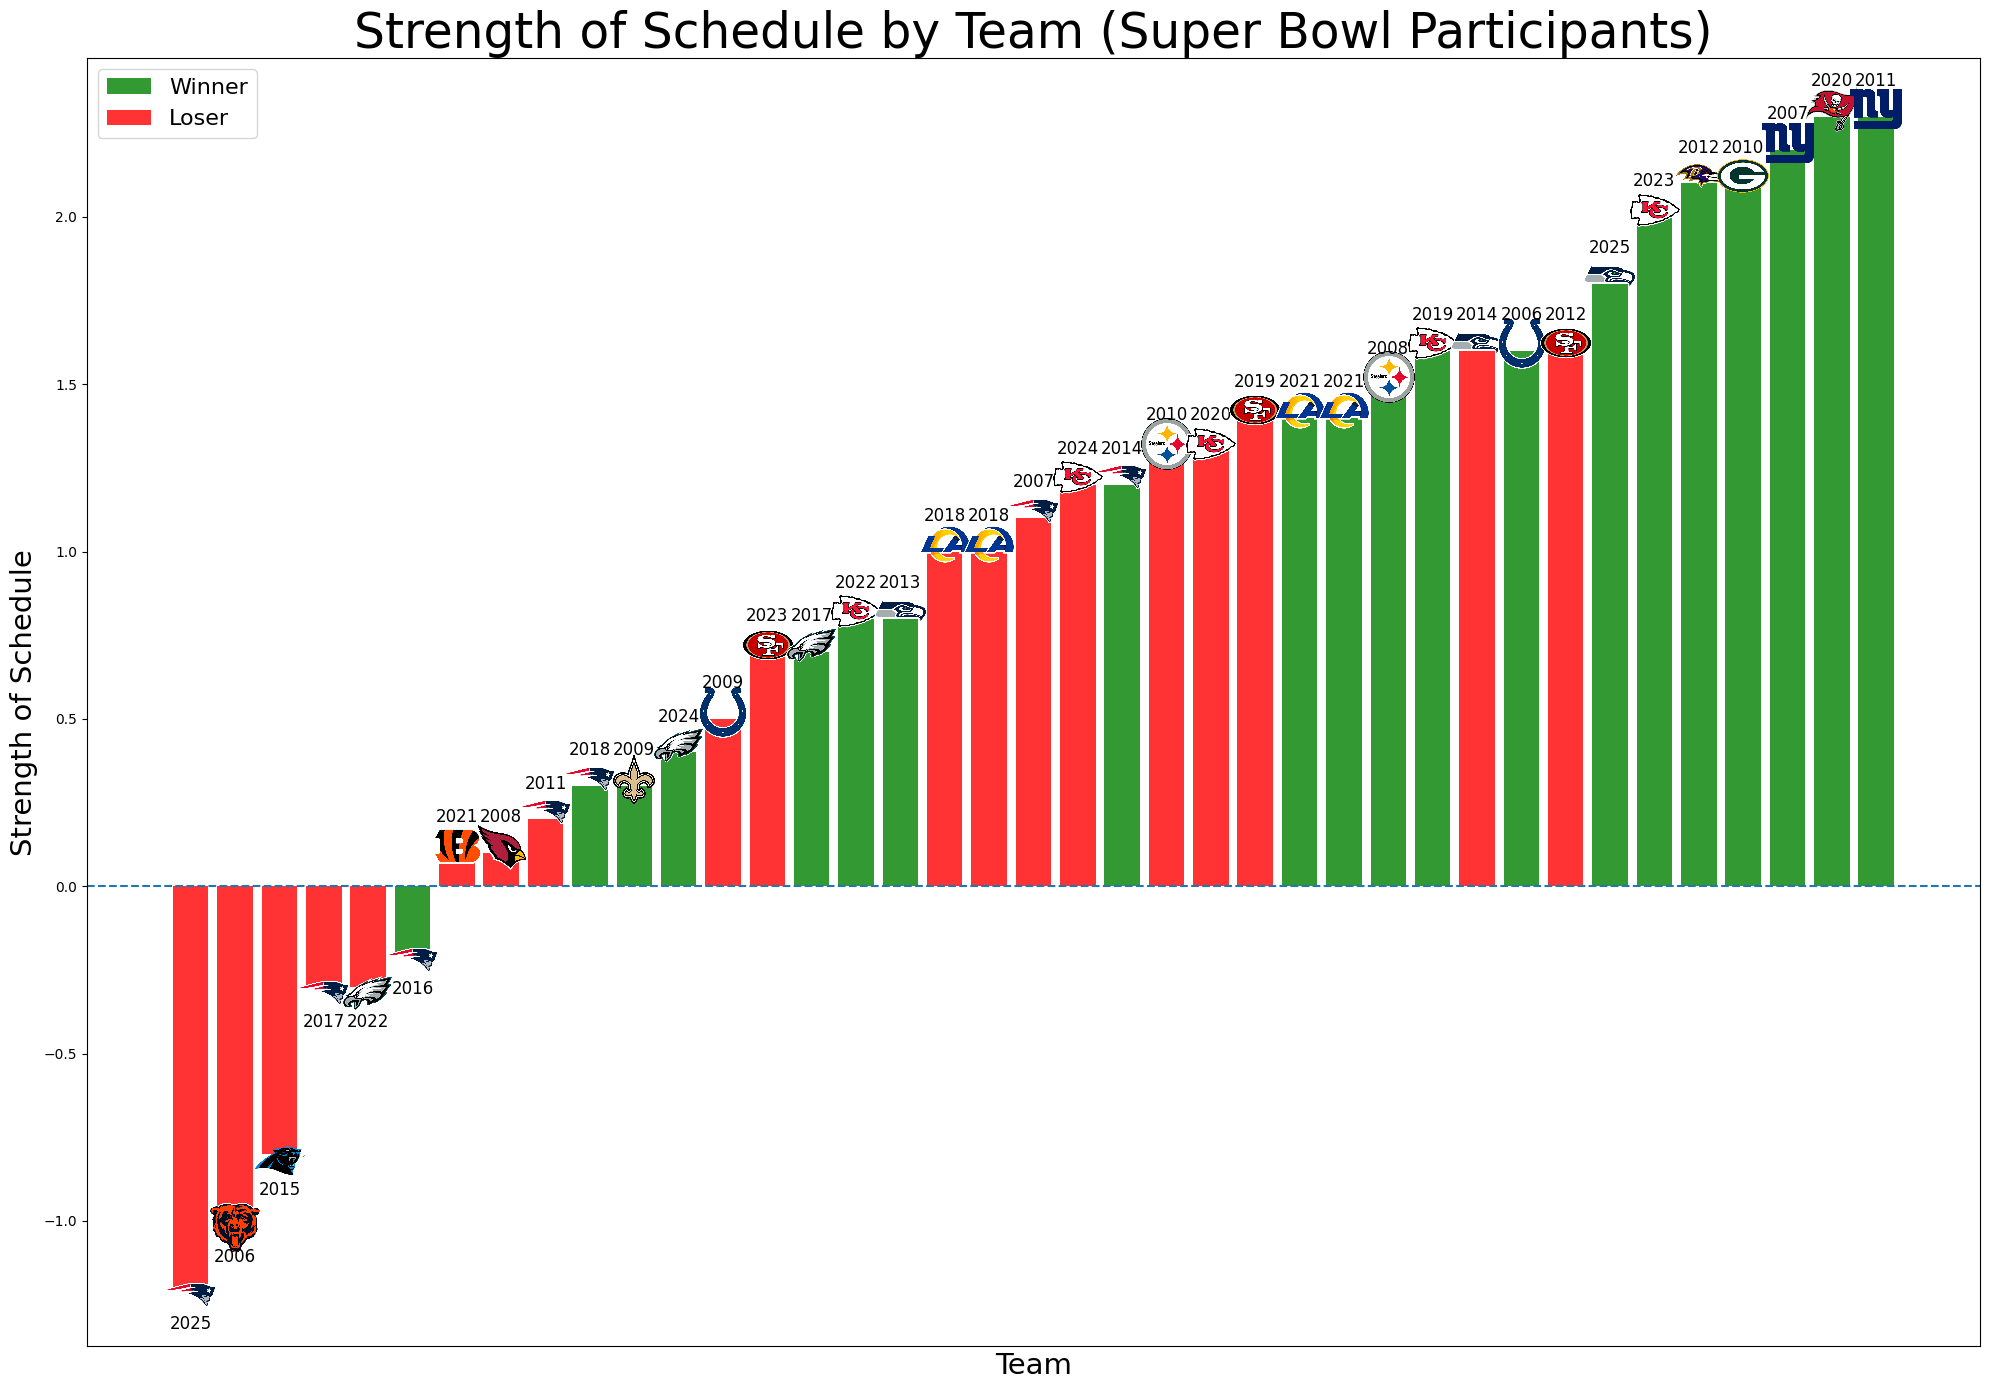

In [45]:
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
import matplotlib.image as mpimg

plt.rcParams["figure.figsize"] = [20, 14]
plt.rcParams["figure.autolayout"] = True

# Sort data by Strength of Schedule 
vis_df1_sorted = vis_df1.sort_values(by='Strength of Schedule (teamrankings.com)')

# Create unique labels (Year + Team)
teams = vis_df1_sorted['Year'].astype(str) + " " + vis_df1_sorted['Team Name']
sos = vis_df1_sorted['Strength of Schedule (teamrankings.com)']
years = vis_df1_sorted['Year'].astype(str)

paths = vis_df1_sorted['Logo Path']

colors = vis_df1_sorted['Winner (Y/N)'].map({'Y': 'green', 'N': 'red'})

# Create plot
fig, ax = plt.subplots()

x_pos = range(len(vis_df1_sorted))

# Bar chart
ax.bar(x_pos, sos, alpha=0.8, color=colors)

# Add reference line at 0
ax.axhline(0, linestyle='--', linewidth=1.5)

# Labels and title
plt.title("Strength of Schedule by Team (Super Bowl Participants)", fontsize=35)
plt.xlabel("Team", fontsize=21)
plt.ylabel("Strength of Schedule", fontsize=21)

ax.set_xticks([])

# Legend
legend_elements = [
    Patch(alpha=0.8, facecolor='green', label='Winner'),
    Patch(alpha=0.8, facecolor='red', label='Loser')
]

ax.legend(handles=legend_elements, fontsize=16, loc='upper left')

# Add logos and year labels dynamically above or below bars
for x, (year, logo_path, bar_height) in enumerate(zip(years, paths, sos)):
    try:
        img = mpimg.imread(logo_path)
        im = OffsetImage(img, zoom=0.08)  # Adjust zoom to fit your plot
        
        if bar_height >= 0:
            offset = bar_height
            xybox = (0, bar_height*0.1 + 5)  # 10% of bar height + 5 pts
            text_y = bar_height + .08
            va_text = 'bottom'
        else:
            offset = bar_height
            xybox = (0, bar_height*0.1 - 5)  # slightly below negative bar
            text_y = bar_height - .08
            va_text = 'top'
        
        ab = AnnotationBbox(im, (x, offset), xybox=xybox, frameon=False,
                            xycoords='data', boxcoords="offset points", pad=0)
        ax.add_artist(ab)
        
        # Add year text
        ax.text(x, text_y, year, ha='center', va=va_text, fontsize=12)
    except FileNotFoundError:
        print(f"Logo not found for year {year}: {logo_path}")

plt.tight_layout()
plt.show()